<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-NhatCuong/Face-Based-Employee-Check-in-System/blob/main/Face_Regconization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!gdown 1w7Riq_itzcijqkvSW0yyivvlw0IgRGa_
#!unzip Dataset.zip

In [ ]:
#!pip install faiss-cpu

Download Dataset

In [ ]:
import os
import faiss
import numpy as np
dataset_path = 'Dataset'
os.listdir(dataset_path)

image_paths = []
labels = []

for filename in os.listdir(dataset_path):
    if filename.endswith(('.jpg', '.JPG', '.png', '.jpeg')):
        image_paths.append(os.path.join(dataset_path, filename))

        # Split filename to get the name without extension
        file_name = filename.split('.')[0]

        # Extracts label starting from the 8th character
        label = file_name[7:]
        labels.append(label)


Tạo labels và image_path


In [ ]:
IMAGE_SIZE = 300
VECTOR_DIM = 300 * 300 * 3

Cấu hình tham số

In [ ]:
index = faiss.IndexFlatL2(VECTOR_DIM)
label_map = []


Khởi tạo FAISS index

In [ ]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Create the DataFrame from the lists you prepared earlier
data = {
    'image_path': image_paths,
    'label': labels
}

df = pd.DataFrame(data)

In [ ]:
def image_to_vector(image_path):
    img = Image.open(image_path).resize((IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.array(img)

    # Handle grayscale images (convert to RGB)
    if len(img_array.shape) == 2:
        img_array = np.stack((img_array,)*3, axis=-1)

    # Normalize pixel values to [0, 1]
    vector = img_array.astype('float32') / 255.0
    return vector.flatten()

Chuyển đổi hình ảnh thành vector

In [ ]:
for idx, row in df.iterrows():
    image_path = row['image_path']
    label = row['label']

    try:
        vector = image_to_vector(image_path)
        index.add(np.array([vector]))
        label_map.append(label)
    except Exception as e:
        print(f"Error processing {image_path}: {e}")

Xây dựng index từ dataframe

In [ ]:
faiss.write_index(index, "employee_images.index")
np.save("label_map.npy", np.array(label_map))


Lưu kết quả

In [ ]:
def search_similar_images(query_image_path, k=5):
    """Search for similar employee images"""
    # Load index and labels
    index = faiss.read_index("employee_images.index")
    label_map = np.load("label_map.npy")

    # Convert query image to vector
    query_vector = image_to_vector(query_image_path)

    # Search in Faiss
    distances, indices = index.search(np.array([query_vector]), k)

    # Get results
    results = []
    for i in range(len(indices[0])):
        employee_name = label_map[indices[0][i]]
        distance = distances[0][i]
        results.append((employee_name, distance))

    return results

Hàm tìm kiếm ảnh tương đồng

In [ ]:
def display_query_and_top_matches(query_image_path):
    query_img = Image.open(query_image_path)
    query_img = query_img.resize((300, 300))

    plt.figure(figsize=(5, 5))
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis('off')
    plt.show()

    matches = search_similar_images(query_image_path)

    """Display the top 5 matching employee images with distances"""
    # Get the image paths for the results
    top_matches = []
    for name, distance in matches:
        # Find the image path for this employee in df
        img_path = df[df['label'] == name]['image_path'].values[0]
        top_matches.append((name, distance, img_path))

    # Create plot
    plt.figure(figsize=(15, 5))
    for i, (name, distance, img_path) in enumerate(top_matches):
        img = Image.open(img_path)
        img = img.resize((300, 300))

        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(f"{name}\nDist: {distance:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

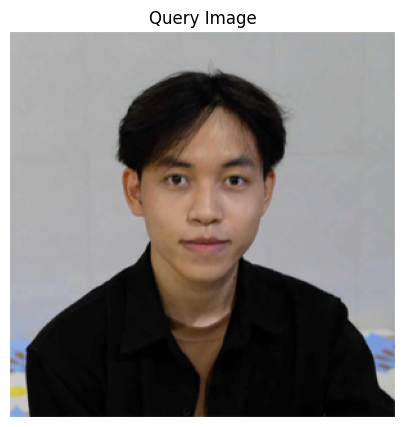

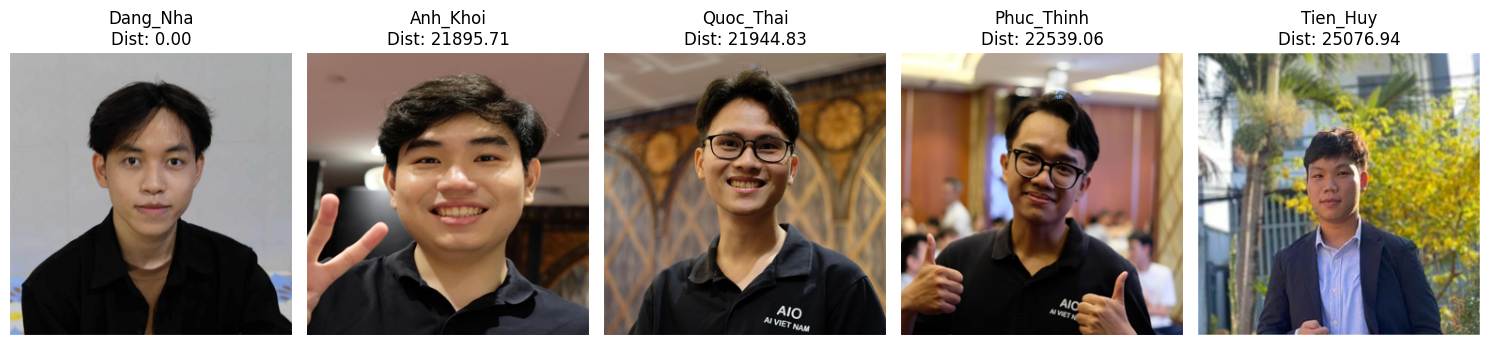

In [ ]:
test_image_path = 'Dataset/Avatar_Dang_Nha.jpg'
display_query_and_top_matches(test_image_path)